In [5]:
from sklearn.datasets import make_regression # generates linear regression data
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [2]:
X , y = make_regression(n_samples=100 , n_features=2 , n_informative=2 , n_targets=1 , noise=50)

In [4]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})
df.head()

,feature1,feature2,target
0,-0.677941,0.527599,-28.269476
1,1.022362,0.821240,10.689414
2,0.265930,0.925395,78.217447
3,-0.394929,2.450557,211.428654
4,-0.731200,1.544088,22.476745


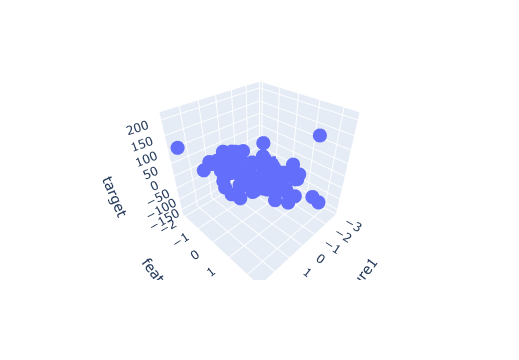

In [7]:
fig = px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = lr.predict(X_test)

In [11]:
print("MAE",mean_absolute_error(y_pred,y_test))
print("MSE",mean_squared_error(y_pred,y_test))
print("R2 Score",r2_score(y_pred,y_test))

MAE 41.954729353536685
MSE 2266.080247543984
R2 Score 0.5145801901008324


In [14]:
x = np.linspace(-5,5,10)
y = np.linspace(-5,5,10)
xGrid , yGrid = np.meshgrid(y,x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final


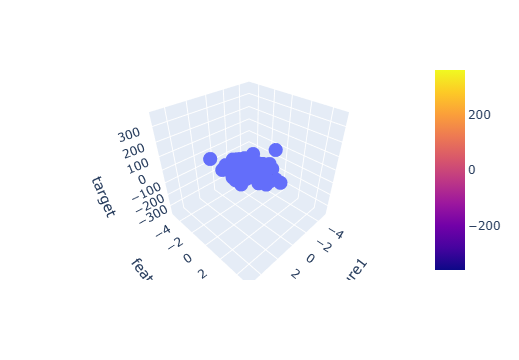

In [15]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [16]:
lr.coef_

array([48.15678819, 24.15555955])

In [17]:
lr.intercept_

np.float64(0.933096632823661)